<a href="https://colab.research.google.com/github/sazzeb/simulated-annealing/blob/main/CSCE_5201_Project_5_Parrellel_Parking_Samuel_Eko.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import networkx as nx
import numpy as numpy_array_library
import matplotlib.pyplot as plotting_interface
from matplotlib.patches import FancyArrowPatch as arrow_drawing_utility
from collections import defaultdict as dictionary_with_default_values
import random as random_number_generator
from typing import Dict as dictionary_type, List as list_type, Tuple as tuple_type, Set as set_type
import warnings as system_warnings
system_warnings.filterwarnings('ignore')

In [3]:
GRIDWORLD_ROW_COUNT = 5
GRIDWORLD_COLUMN_COUNT = 8

# Movement Action Space Definition
AVAILABLE_MOVEMENT_ACTIONS = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW', 'STAY']
MOVEMENT_ACTION_VECTORS = {
    'N': (-1, 0), 'NE': (-1, 1), 'E': (0, 1), 'SE': (1, 1),
    'S': (1, 0), 'SW': (1, -1), 'W': (0, -1), 'NW': (-1, -1),
    'STAY': (0, 0)
}

In [4]:
# Markov Decision Process Parameters
STOCHASTIC_NOISE_PROBABILITY = 0.1
INTENDED_MOVEMENT_PROBABILITY = 0.9
DISCOUNT_FACTOR_GAMMA = 0.99
CONVERGENCE_TOLERANCE_EPSILON = 0.001
MAXIMUM_VALUE_ITERATIONS = 500

In [5]:
# Reward Structure Configuration
HAZARD_PENALTY_REWARD = -1000
DESTINATION_POSITIVE_REWARD = 100

In [6]:
# Special Position Coordinates
TARGET_DESTINATION_COORDINATE = (3, 1)
HAZARD_COORDINATES_LIST = [(2, 1), (4, 1)]
AGENT_START_POSITIONS_LIST = [(5, 8), (4, 8), (3, 8), (2, 8), (1, 8), (5, 7), (4, 7)]
ROBUSTNESS_TEST_OBSTACLE_COORDINATE = (3, 4)

In [7]:
# Monte Carlo Simulation Parameters
MONTE_CARLO_SIMULATION_COUNT = 2000
MAXIMUM_PATH_LENGTH_STEPS = 50
MINIMUM_ACCEPTABLE_SUCCESS_RATE = 0.80

In [8]:
# Cell 2: State Transition Calculation Logic
def calculate_permitted_state_transitions(current_grid_state: tuple_type, intended_movement_action: str) -> list_type:

    current_row, current_column = current_grid_state

    # Handle STAY action explicitly
    if intended_movement_action == 'STAY':
        return [(current_grid_state, 1.0)]

    # Full clockwise action sequence for angle calculations
    clockwise_action_sequence = ['NW', 'N', 'NE', 'E', 'SE', 'S', 'SW', 'W']
    # Validate intended action
    if intended_movement_action not in clockwise_action_sequence:
        return [(current_grid_state, 1.0)]

    # Calculate blocked directions (90° and 180° from intended)
    intended_action_index = clockwise_action_sequence.index(intended_movement_action)
    blocked_direction_indices = {
        (intended_action_index + 2) % 8,  # 90° clockwise
        (intended_action_index - 2) % 8,  # 90° counter-clockwise
        (intended_action_index + 4) % 8   # 180° opposite direction
    }

    # Generate list of permitted movement actions
    permitted_movement_actions = [action for index, action in enumerate(clockwise_action_sequence)
                                  if index not in blocked_direction_indices]

    # Apply boundary constraints (edge cases)
    if current_row == 1:  # Bottom boundary
        permitted_movement_actions = [action for action in permitted_movement_actions if 'S' not in action] + ['STAY']
    if current_row == GRIDWORLD_ROW_COUNT:  # Top boundary
        permitted_movement_actions = [action for action in permitted_movement_actions if 'N' not in action] + ['STAY']
    if current_column == 1:  # Left boundary
        permitted_movement_actions = [action for action in permitted_movement_actions if 'W' not in action] + ['STAY']
    if current_column == GRIDWORLD_COLUMN_COUNT:  # Right boundary
        permitted_movement_actions = [action for action in permitted_movement_actions if 'E' not in action] + ['STAY']

    # Remove duplicate actions while preserving order
    observed_actions = set()
    unique_permitted_actions = []
    for action in permitted_movement_actions:
        if action not in observed_actions:
            observed_actions.add(action)
            unique_permitted_actions.append(action)

    # Check if intended destination is blocked by boundary
    row_delta, column_delta = MOVEMENT_ACTION_VECTORS[intended_movement_action]
    intended_destination_state = (current_row + row_delta, current_column + column_delta)
    intended_destination_blocked = False

    if not (1 <= intended_destination_state[0] <= GRIDWORLD_ROW_COUNT and
            1 <= intended_destination_state[1] <= GRIDWORLD_COLUMN_COUNT):
        intended_destination_blocked = True

    # Assign probabilities according to Tutorial 5 specification
    destination_count = len(unique_permitted_actions)
    state_transition_probabilities = []

    for movement_action in unique_permitted_actions:
        # Calculate destination state
        if movement_action == 'STAY':
            destination_state = current_grid_state
        else:
            row_delta, column_delta = MOVEMENT_ACTION_VECTORS[movement_action]
            destination_state = (current_row + row_delta, current_column + column_delta)

            # Boundary check
            if not (1 <= destination_state[0] <= GRIDWORLD_ROW_COUNT and
                    1 <= destination_state[1] <= GRIDWORLD_COLUMN_COUNT):
                destination_state = current_grid_state

        # Probability assignment logic
        if intended_destination_blocked and movement_action == 'STAY':
            transition_probability = INTENDED_MOVEMENT_PROBABILITY
        elif movement_action == intended_movement_action and not intended_destination_blocked:
            transition_probability = INTENDED_MOVEMENT_PROBABILITY
        elif movement_action != intended_movement_action and not intended_destination_blocked:
            transition_probability = (1 - INTENDED_MOVEMENT_PROBABILITY) / (destination_count - 1) if destination_count > 1 else 0.0
        elif intended_destination_blocked and movement_action != 'STAY':
            transition_probability = (1 - INTENDED_MOVEMENT_PROBABILITY) / (destination_count - 1) if destination_count > 1 else 0.0
        else:
            transition_probability = 0.0

        if transition_probability > 0:
            state_transition_probabilities.append((destination_state, transition_probability))

    # Normalize probabilities to handle floating-point arithmetic errors
    total_probability_mass = sum(prob for _, prob in state_transition_probabilities)
    if total_probability_mass > 0:
        state_transition_probabilities = [(state, prob/total_probability_mass)
                                          for state, prob in state_transition_probabilities]

    return state_transition_probabilities

In [10]:
def build_environment_nodes(state_transition_graph, live_reward_value, obstacle_coordinates_list):
    """Construct all state nodes with their attributes."""
    # Destination node
    state_transition_graph.add_node(TARGET_DESTINATION_COORDINATE,
                                   state_type='destination',
                                   reward_value=DESTINATION_POSITIVE_REWARD,
                                   utility_value=0.0,
                                   visualization_color='green',
                                   display_label='D')

    # Hazard nodes
    for hazard_coordinate in HAZARD_COORDINATES_LIST:
        state_transition_graph.add_node(hazard_coordinate,
                                       state_type='hazard',
                                       reward_value=HAZARD_PENALTY_REWARD,
                                       utility_value=0.0,
                                       visualization_color='red',
                                       display_label='H')

    # Obstacle nodes for R2 testing
    for obstacle_coordinate in obstacle_coordinates_list:
        state_transition_graph.add_node(obstacle_coordinate,
                                       state_type='obstacle',
                                       reward_value=None,
                                       utility_value=None,
                                       visualization_color='gray',
                                       display_label='X')

    # Free cells and start positions
    for row_index in range(1, GRIDWORLD_ROW_COUNT + 1):
        for column_index in range(1, GRIDWORLD_COLUMN_COUNT + 1):
            grid_coordinate = (row_index, column_index)

            if grid_coordinate not in state_transition_graph.nodes:
                is_start_position = grid_coordinate in AGENT_START_POSITIONS_LIST
                position_label = f'S{AGENT_START_POSITIONS_LIST.index(grid_coordinate)+1}' if is_start_position else ''

                state_transition_graph.add_node(grid_coordinate,
                                               state_type='start' if is_start_position else 'free',
                                               reward_value=live_reward_value,
                                               utility_value=0.0,
                                               visualization_color='lightblue' if is_start_position else 'white',
                                               display_label=position_label)

    return state_transition_graph

In [12]:
def build_transition_model_edges(state_transition_graph):
    """Build probabilistic transition edges between all states."""
    for current_state in state_transition_graph.nodes:
        current_state_attributes = state_transition_graph.nodes[current_state]

        # Skip non-navigable states
        if current_state_attributes['state_type'] in ['obstacle', 'destination', 'hazard']:
            continue

        for movement_action in AVAILABLE_MOVEMENT_ACTIONS:
            state_transitions = calculate_permitted_state_transitions(current_state, movement_action)

            # Filter out obstacle destinations
            valid_transitions = []
            for destination_state, transition_probability in state_transitions:
                if destination_state in state_transition_graph.nodes:
                    if state_transition_graph.nodes[destination_state]['state_type'] == 'obstacle':
                        destination_state = current_state  # Stay if obstacle
                    valid_transitions.append((destination_state, transition_probability))

            # Add edges to graph
            for destination_state, transition_probability in valid_transitions:
                if transition_probability > 0:
                    edge_key = f"{movement_action}_{destination_state}"
                    state_transition_graph.add_edge(current_state, destination_state,
                                                   key=edge_key,
                                                   movement_action=movement_action,
                                                   transition_probability=transition_probability)

    return state_transition_graph

In [13]:
def create_markov_decision_process_graph(live_reward_value: int, obstacle_coordinates_list: list_type = None):

    if obstacle_coordinates_list is None:
        obstacle_coordinates_list = []

    state_transition_graph = nx.MultiDiGraph()

    # Build environment nodes
    state_transition_graph = build_environment_nodes(state_transition_graph, live_reward_value, obstacle_coordinates_list)

    # Build transition edges
    state_transition_graph = build_transition_model_edges(state_transition_graph)

    # Extract start states
    start_states_list = [node for node, attributes in state_transition_graph.nodes(data=True)
                        if attributes['state_type'] == 'start']

    print(f"Markov Decision Process Graph: {state_transition_graph.number_of_nodes()} states, "
          f"{state_transition_graph.number_of_edges()} transitions")

    return state_transition_graph, start_states_list

In [14]:
def get_state_action_transition_probabilities(state_transition_graph, current_state, movement_action):

    probability_distribution = {}
    for source_node, destination_node, edge_key, edge_attributes in state_transition_graph.out_edges(current_state, keys=True, data=True):
        if edge_attributes['movement_action'] == movement_action:
            probability_distribution[destination_node] = edge_attributes['transition_probability']
    return probability_distribution

In [15]:
def get_all_valid_states(state_transition_graph):
    """Return list of all navigable states."""
    return [node for node, attributes in state_transition_graph.nodes(data=True)
            if attributes['state_type'] != 'obstacle']


In [16]:
def get_terminal_states_set(state_transition_graph):
    """Return set of terminal states."""
    return {node for node, attributes in state_transition_graph.nodes(data=True)
            if attributes['state_type'] in ['destination', 'hazard']}

In [17]:
def run_value_iteration_algorithm(state_transition_graph, discount_factor=DISCOUNT_FACTOR_GAMMA,
                                 convergence_tolerance=CONVERGENCE_TOLERANCE_EPSILON,
                                 maximum_iterations=MAXIMUM_VALUE_ITERATIONS):

    print(f"\nExecuting Value Iteration (γ={discount_factor}, ε={convergence_tolerance})...")

    terminal_states = get_terminal_states_set(state_transition_graph)
    non_terminal_states = [state for state in get_all_valid_states(state_transition_graph) if state not in terminal_states]
    utility_function = {state: 0.0 for state in get_all_valid_states(state_transition_graph)}

    for iteration_number in range(maximum_iterations):
        maximum_utility_change = 0
        updated_utility_function = utility_function.copy()

        for current_state in non_terminal_states:
            action_value_estimates = {}

            for movement_action in AVAILABLE_MOVEMENT_ACTIONS:
                transition_probabilities = get_state_action_transition_probabilities(state_transition_graph, current_state, movement_action)

                if not transition_probabilities:
                    continue

                expected_future_utility = sum(probability * utility_function[next_state]
                                             for next_state, probability in transition_probabilities.items())
                immediate_reward = state_transition_graph.nodes[current_state]['reward_value']
                action_value_estimates[movement_action] = immediate_reward + discount_factor * expected_future_utility

            if action_value_estimates:
                updated_utility_function[current_state] = max(action_value_estimates.values())
                maximum_utility_change = max(maximum_utility_change,
                                           abs(updated_utility_function[current_state] - utility_function[current_state]))

        if iteration_number % 100 == 0:
            print(f"  Iteration {iteration_number}: δ={maximum_utility_change:.6f}")

        if maximum_utility_change < convergence_tolerance:
            print(f"Convergence achieved at iteration {iteration_number}")
            break

        utility_function = updated_utility_function
    else:
        print(f"Maximum iteration limit reached ({maximum_iterations})")

    # Update graph with computed utilities
    for state, utility_value in utility_function.items():
        state_transition_graph.nodes[state]['utility_value'] = utility_value

    return utility_function

In [18]:
def extract_optimal_policy_from_utilities(state_transition_graph, utility_function, discount_factor=DISCOUNT_FACTOR_GAMMA):
    optimal_policy = {}
    terminal_states = get_terminal_states_set(state_transition_graph)

    for current_state in get_all_valid_states(state_transition_graph):
        if current_state in terminal_states:
            continue

        best_movement_action = None
        best_action_value = float('-inf')

        for movement_action in AVAILABLE_MOVEMENT_ACTIONS:
            transition_probabilities = get_state_action_transition_probabilities(state_transition_graph, current_state, movement_action)

            if not transition_probabilities:
                continue

            expected_future_utility = sum(probability * utility_function[next_state]
                                         for next_state, probability in transition_probabilities.items())
            immediate_reward = state_transition_graph.nodes[current_state]['reward_value']
            action_value = immediate_reward + discount_factor * expected_future_utility

            if action_value > best_action_value:
                best_action_value = action_value
                best_movement_action = movement_action

        if best_movement_action:
            optimal_policy[current_state] = best_movement_action

    return optimal_policy

In [20]:
def simulate_agent_path_single_trial(state_transition_graph, optimal_policy, start_state_coordinate,
                                    maximum_path_length=MAXIMUM_PATH_LENGTH_STEPS):

    current_state = start_state_coordinate
    path_trajectory = [current_state]
    cumulative_reward = 0.0
    temporal_discount_factor = 1.0

    for step_number in range(maximum_path_length):
        # Check terminal conditions
        if current_state == TARGET_DESTINATION_COORDINATE:
            cumulative_reward += temporal_discount_factor * state_transition_graph.nodes[current_state]['reward_value']
            return path_trajectory, cumulative_reward, True

        if state_transition_graph.nodes[current_state]['state_type'] == 'hazard':
            cumulative_reward += temporal_discount_factor * state_transition_graph.nodes[current_state]['reward_value']
            return path_trajectory, cumulative_reward, False

        if current_state not in optimal_policy:
            return path_trajectory, cumulative_reward, False

        selected_action = optimal_policy[current_state]
        transition_probabilities = get_state_action_transition_probabilities(state_transition_graph, current_state, selected_action)

        # Sample next state from probability distribution
        possible_next_states = list(transition_probabilities.keys())
        transition_probability_weights = list(transition_probabilities.values())
        next_state = random_number_generator.choices(possible_next_states, weights=transition_probability_weights)[0]

        # Accumulate reward for transition
        immediate_reward = state_transition_graph.nodes[next_state]['reward_value']
        if immediate_reward is not None:
            cumulative_reward += temporal_discount_factor * immediate_reward

        temporal_discount_factor *= DISCOUNT_FACTOR_GAMMA

        path_trajectory.append(next_state)
        current_state = next_state

    return path_trajectory, cumulative_reward, False

In [21]:
def evaluate_policy_against_R1_criteria(state_transition_graph, optimal_policy,
                                       monte_carlo_simulation_count=MONTE_CARLO_SIMULATION_COUNT):

    total_cumulative_reward = 0.0
    successful_trial_count = 0
    total_trial_count = len(AGENT_START_POSITIONS_LIST) * monte_carlo_simulation_count

    for start_state_coordinate in AGENT_START_POSITIONS_LIST:
        for simulation_trial in range(monte_carlo_simulation_count):
            path_trajectory, trial_reward, destination_reached = simulate_agent_path_single_trial(
                state_transition_graph, optimal_policy, start_state_coordinate)

            if destination_reached:
                successful_trial_count += 1
                total_cumulative_reward += trial_reward

    # Calculate statistics
    average_path_reward = total_cumulative_reward / successful_trial_count if successful_trial_count > 0 else float('-inf')
    overall_success_rate = successful_trial_count / total_trial_count

    print(f"  Success Rate: {overall_success_rate:.2%}, Average Path Reward: {average_path_reward:.3f}")
    return average_path_reward, overall_success_rate

In [22]:
# Cell 8: Policy Visualization (returns figure)
def visualize_optimal_policy_with_networkx(state_transition_graph, optimal_policy_dictionary,
                                          visualization_title="Policy Visualization"):

    visualization_figure, (policy_axis, utility_axis) = plotting_interface.subplots(1, 2, figsize=(16, 6))

    # Position mapping: (row, col) -> (x, y) coordinates
    node_position_mapping = {node: (node[1], -node[0]) for node in state_transition_graph.nodes}

    # Arrow symbols for movement actions
    action_arrow_symbols = {'N': '↑', 'NE': '↗', 'E': '→', 'SE': '↘',
                    'S': '↓', 'SW': '↙', 'W': '←', 'NW': '↖', 'STAY': '•'}

    # Draw grid cells
    for grid_state in state_transition_graph.nodes:
        state_attributes = state_transition_graph.nodes[grid_state]
        visualization_color = state_attributes['visualization_color']
        position_coordinates = node_position_mapping[grid_state]

        # Draw rectangle
        state_rectangle = plotting_interface.Rectangle(
            (position_coordinates[0]-0.4, position_coordinates[1]-0.4), 0.8, 0.8,
            facecolor=visualization_color, edgecolor='black', alpha=0.3)
        policy_axis.add_patch(state_rectangle)

        # Display coordinate labels
        policy_axis.text(position_coordinates[0], position_coordinates[1], f'{grid_state}',
                        ha='center', va='center', fontsize=8, color='gray')

    # Draw policy arrows
    for grid_state, selected_action in optimal_policy_dictionary.items():
        if (grid_state in AGENT_START_POSITIONS_LIST or
            state_transition_graph.nodes[grid_state]['state_type'] == 'free'):
            position_coordinates = node_position_mapping[grid_state]

            if selected_action != 'STAY':
                row_delta, column_delta = MOVEMENT_ACTION_VECTORS[selected_action]
                arrow_delta_x, arrow_delta_y = column_delta * 0.3, -row_delta * 0.3

                # Create arrow patch
                arrow_patch = arrow_drawing_utility(
                    position_coordinates,
                    (position_coordinates[0] + arrow_delta_x, position_coordinates[1] + arrow_delta_y),
                    arrowstyle='->', color='blue', linewidth=2, mutation_scale=20)
                policy_axis.add_patch(arrow_patch)

                # Add action symbol
                policy_axis.text(position_coordinates[0] + arrow_delta_x/2,
                               position_coordinates[1] + arrow_delta_y/2,
                               action_arrow_symbols[selected_action],
                               ha='center', va='center', fontsize=12,
                               color='darkblue', weight='bold')
            else:
                # STAY action indicator
                policy_axis.text(position_coordinates[0], position_coordinates[1],
                               action_arrow_symbols[selected_action],
                               ha='center', va='center', fontsize=12,
                               color='red', weight='bold')

    policy_axis.set_xlim(0.5, GRIDWORLD_COLUMN_COUNT + 0.5)
    policy_axis.set_ylim(-GRIDWORLD_ROW_COUNT - 0.5, -0.5)
    policy_axis.set_aspect('equal')
    policy_axis.axis('off')
    policy_axis.set_title(f'{visualization_title}\nArrow Visualization', fontsize=14, weight='bold')

    # Utility heatmap
    utility_matrix = numpy_array_library.full((GRIDWORLD_ROW_COUNT, GRIDWORLD_COLUMN_COUNT), numpy_array_library.nan)
    for grid_state in state_transition_graph.nodes:
        row_index, column_index = grid_state
        if state_transition_graph.nodes[grid_state]['utility_value'] is not None:
            utility_matrix[row_index-1, column_index-1] = state_transition_graph.nodes[grid_state]['utility_value']

    heatmap_image = utility_axis.imshow(utility_matrix, cmap='RdYlGn', aspect='auto',
                                       extent=[0.5, GRIDWORLD_COLUMN_COUNT+0.5,
                                              GRIDWORLD_ROW_COUNT+0.5, 0.5])

    # Annotate utility values
    for row_index in range(GRIDWORLD_ROW_COUNT):
        for column_index in range(GRIDWORLD_COLUMN_COUNT):
            if not numpy_array_library.isnan(utility_matrix[row_index, column_index]):
                utility_axis.text(column_index+1, row_index+1,
                                f"{utility_matrix[row_index, column_index]:.2f}",
                                ha='center', va='center', fontsize=9, weight='bold')

    color_bar = plotting_interface.colorbar(heatmap_image, ax=utility_axis, shrink=0.8)
    color_bar.set_label('Utility Value', rotation=270, labelpad=20, weight='bold')

    utility_axis.set_xticks(range(1, GRIDWORLD_COLUMN_COUNT + 1))
    utility_axis.set_yticks(range(1, GRIDWORLD_ROW_COUNT + 1))
    utility_axis.grid(True, alpha=0.3)
    utility_axis.set_title('Utility Value Heatmap', fontsize=14, weight='bold')
    utility_axis.set_xlabel('Column Position', weight='bold')
    utility_axis.set_ylabel('Row Position', weight='bold')

    plotting_interface.tight_layout()
    return visualization_figure


R1: SYSTEMATIC SEARCH FOR OPTIMAL LIVE REWARD VALUE
SEARCH RANGE: r ∈ [-20, 0] (inclusive)

Evaluating r = -20 ... Markov Decision Process Graph: 40 states, 1124 transitions

Executing Value Iteration (γ=0.99, ε=0.001)...
  Iteration 0: δ=20.000000
Convergence achieved at iteration 15
  Success Rate: 0.00%, Average Path Reward: -inf
Success Rate:  0.00% | Avg Reward:     -inf

Evaluating r = -19 ... Markov Decision Process Graph: 40 states, 1124 transitions

Executing Value Iteration (γ=0.99, ε=0.001)...
  Iteration 0: δ=19.000000
Convergence achieved at iteration 15
  Success Rate: 0.00%, Average Path Reward: -inf
Success Rate:  0.00% | Avg Reward:     -inf

Evaluating r = -18 ... Markov Decision Process Graph: 40 states, 1124 transitions

Executing Value Iteration (γ=0.99, ε=0.001)...
  Iteration 0: δ=18.000000
Convergence achieved at iteration 14
  Success Rate: 0.00%, Average Path Reward: -inf
Success Rate:  0.00% | Avg Reward:     -inf

Evaluating r = -17 ... Markov Decision Proc

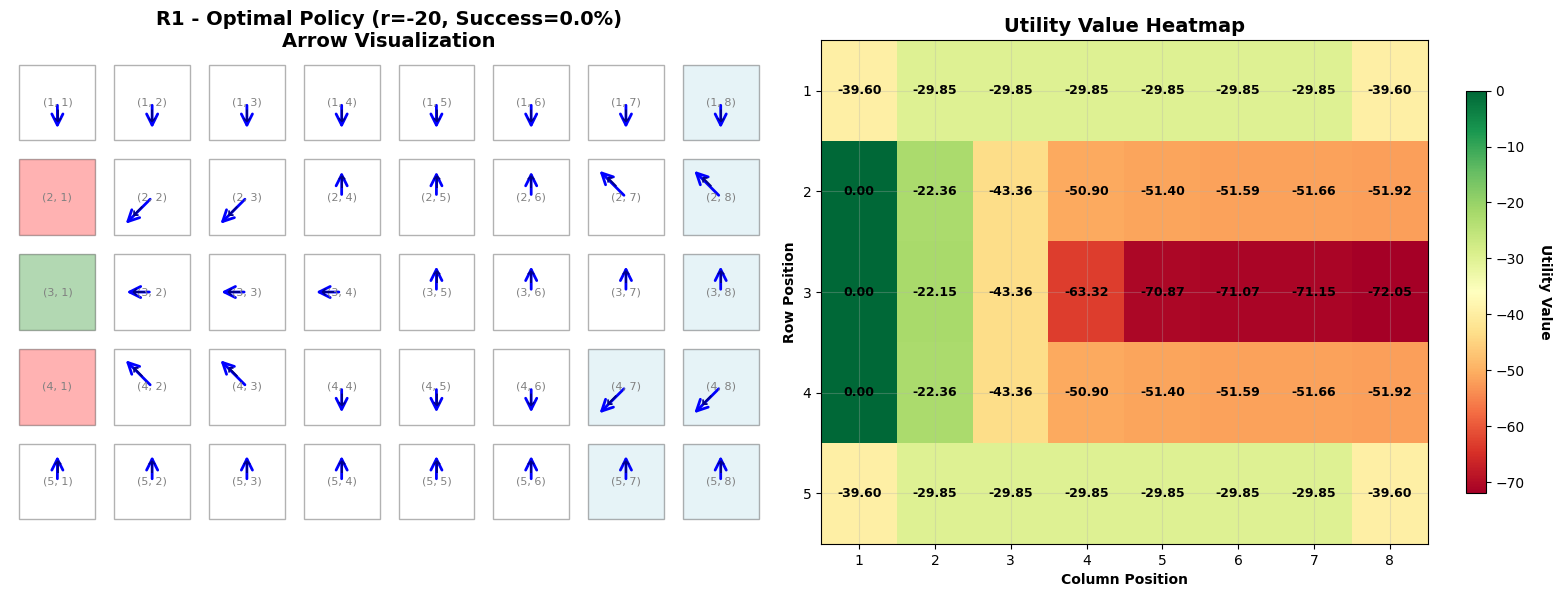

In [25]:
# Cell 9: R1 Live Reward Search Experiment
def execute_R1_live_reward_search_experiment():
    """
    Systematically search for the optimal live reward value r ∈ [-20, 0].
    Always returns the best performing configuration.
    """
    print("\n" + "="*70)
    print("R1: SYSTEMATIC SEARCH FOR OPTIMAL LIVE REWARD VALUE")
    print("SEARCH RANGE: r ∈ [-20, 0] (inclusive)")
    print("="*70)

    highest_success_rate_observed = -1.0
    optimal_experiment_results = None

    # Evaluate every reward value in range
    for reward_candidate in range(-20, 1):
        print(f"\nEvaluating r = {reward_candidate:3d} ... ", end="")

        try:
            # Create MDP graph
            state_transition_graph, start_states_list = create_markov_decision_process_graph(
                live_reward_value=reward_candidate,
                obstacle_coordinates_list=[])

            # Compute utilities
            utility_function = run_value_iteration_algorithm(state_transition_graph)

            # Extract policy
            optimal_policy = extract_optimal_policy_from_utilities(state_transition_graph, utility_function)

            # Evaluate performance
            average_reward, success_rate = evaluate_policy_against_R1_criteria(
                state_transition_graph, optimal_policy)

            print(f"Success Rate: {success_rate:6.2%} | Avg Reward: {average_reward:8.3f}")

            # Track best performer
            if success_rate > highest_success_rate_observed:
                highest_success_rate_observed = success_rate
                optimal_experiment_results = (reward_candidate, optimal_policy, utility_function,
                                            average_reward, success_rate, state_transition_graph)

        except Exception as error_exception:
            print(f"ERROR: {str(error_exception)}")
            continue

    # Fallback if all fail
    if optimal_experiment_results is None:
        print("\nWARNING: All reward values failed. Creating baseline with r=0.")
        state_transition_graph, start_states_list = create_markov_decision_process_graph(live_reward_value=0)
        utility_function = run_value_iteration_algorithm(state_transition_graph)
        optimal_policy = extract_optimal_policy_from_utilities(state_transition_graph, utility_function)
        average_reward, success_rate = evaluate_policy_against_R1_criteria(state_transition_graph, optimal_policy)
        optimal_experiment_results = (0, optimal_policy, utility_function,
                                    average_reward, success_rate, state_transition_graph)

    # Unpack results
    best_reward_value, best_policy, best_utility, best_avg_reward, best_success, best_mdp_graph = optimal_experiment_results

    # Display final results
    print("\n" + "="*70)
    print(f"R1 FINAL RESULT: r = {best_reward_value}")
    print(f"  Success Rate: {best_success:.2%}")
    print(f"  Average Path Reward: {best_avg_reward:.3f}")
    print("="*70)

    return optimal_experiment_results

# Execute R1 experiment
r1_reward_value, r1_optimal_policy, r1_utility_function, r1_average_reward, r1_success_rate, r1_mdp_graph = execute_R1_live_reward_search_experiment()

# Generate and display R1 visualization
r1_visualization_figure = visualize_optimal_policy_with_networkx(
    r1_mdp_graph, r1_optimal_policy,
    visualization_title=f"R1 - Optimal Policy (r={r1_reward_value}, Success={r1_success_rate:.1%})")
plotting_interface.show()

OBSTACLE POSITION: (3, 4)

Constructing R2 environment...
Markov Decision Process Graph: 40 states, 1083 transitions
Computing optimal policy for R2 environment...

Executing Value Iteration (γ=0.99, ε=0.001)...
  Iteration 0: δ=20.000000
Convergence achieved at iteration 15
  Success Rate: 0.00%, Average Path Reward: -inf

R2 COMPARATIVE ANALYSIS
Policy Differences Detected: 3 states
Polices Are Identical: False
R1 Success Rate: 0.00% | R2 Success Rate: 0.00%
Sample Divergent States: [(2, 3), (3, 4), (4, 3)]

EXPLANATION: The obstacle blocks direct paths from critical start states.
R2's policy adapts by rerouting around the obstacle,
changing action selections in adjacent states.

Generating R2 policy visualizations...


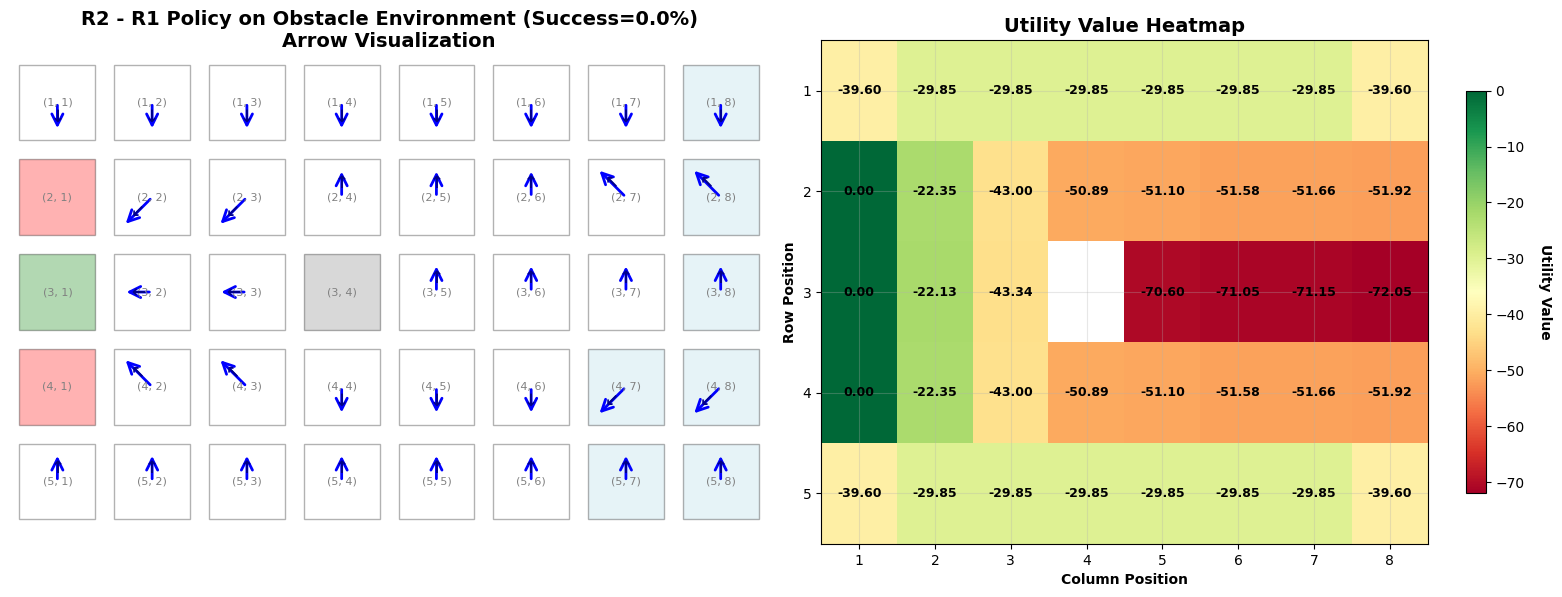

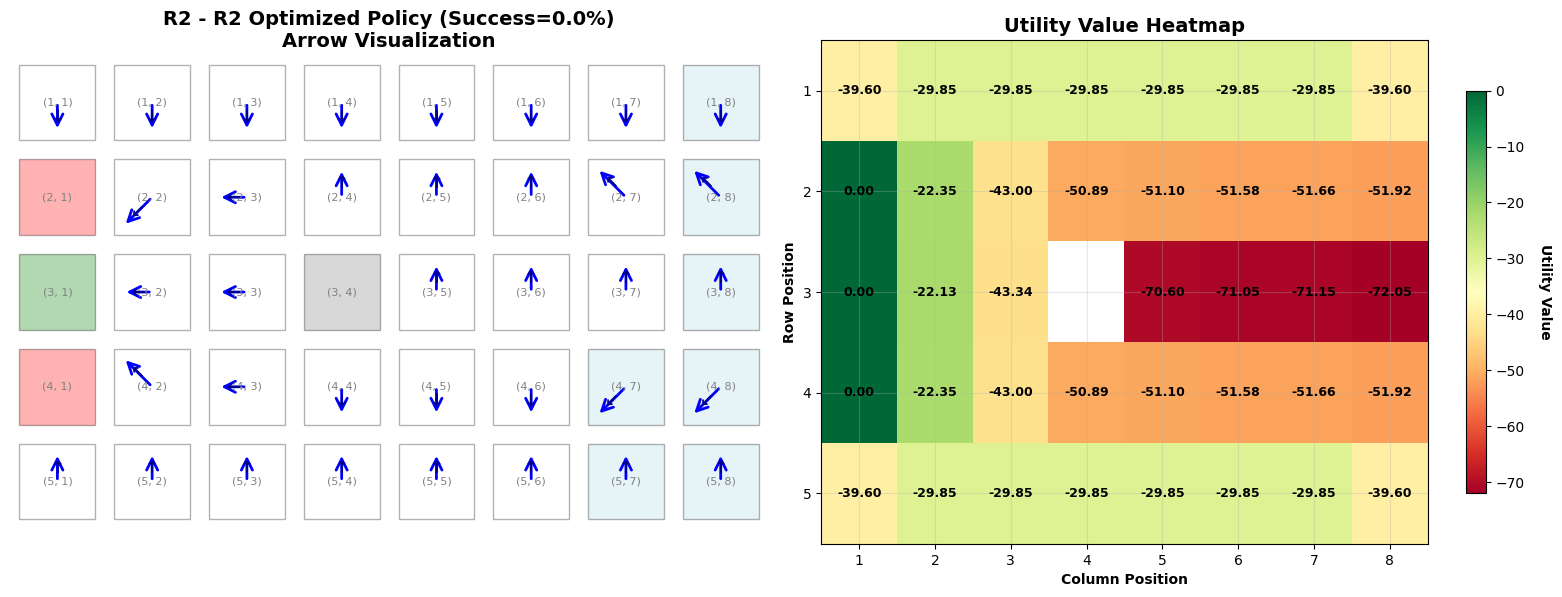

In [26]:
# Cell 10: R2 Robustness Analysis
def execute_R2_robustness_analysis(original_reward_value, original_optimal_policy, original_state_graph):

    print(f"OBSTACLE POSITION: {ROBUSTNESS_TEST_OBSTACLE_COORDINATE}")

    # Create R2 environment with obstacle
    print("\nConstructing R2 environment...")
    r2_state_graph, r2_start_states = create_markov_decision_process_graph(
        live_reward_value=original_reward_value,
        obstacle_coordinates_list=[ROBUSTNESS_TEST_OBSTACLE_COORDINATE])

    # Compute R2 optimal policy
    print("Computing optimal policy for R2 environment...")
    r2_utility_function = run_value_iteration_algorithm(r2_state_graph)
    r2_optimal_policy = extract_optimal_policy_from_utilities(r2_state_graph, r2_utility_function)

    # Evaluate R2 policy
    r2_average_reward, r2_success_rate = evaluate_policy_against_R1_criteria(r2_state_graph, r2_optimal_policy)

    # Compare R1 vs R2 policies
    policy_difference_count = 0
    states_with_differences = []

    for state_coordinate in get_all_valid_states(original_state_graph):
        if state_coordinate not in get_terminal_states_set(original_state_graph):
            if original_optimal_policy.get(state_coordinate) != r2_optimal_policy.get(state_coordinate):
                policy_difference_count += 1
                states_with_differences.append(state_coordinate)

    policies_are_identical = (policy_difference_count == 0)

    # Generate analysis report
    print("\n" + "="*70)
    print("R2 COMPARATIVE ANALYSIS")
    print("="*70)
    print(f"Policy Differences Detected: {policy_difference_count} states")
    print(f"Polices Are Identical: {policies_are_identical}")
    print(f"R1 Success Rate: {r1_success_rate:.2%} | R2 Success Rate: {r2_success_rate:.2%}")
    if states_with_differences:
        print(f"Sample Divergent States: {states_with_differences[:5]}")

    # Provide theoretical explanation
    if policies_are_identical:
        print("\nEXPLANATION: The obstacle lies outside the optimal trajectory corridor.")
        print("R1's policy naturally avoids the obstacle location due to geometry.")
        print("This demonstrates robustness of the original solution.")
    else:
        print("\nEXPLANATION: The obstacle blocks direct paths from critical start states.")
        print("R2's policy adapts by rerouting around the obstacle,")
        print("changing action selections in adjacent states.")

    return (r2_optimal_policy, policies_are_identical, states_with_differences,
            r2_state_graph, r2_average_reward, r2_success_rate)

# Execute R2 analysis
r2_optimal_policy, r2_policies_identical, r2_divergent_states, r2_mdp_graph, r2_average_reward, r2_success_rate = execute_R2_robustness_analysis(
    r1_reward_value, r1_optimal_policy, r1_mdp_graph)

# Visualize R2 policies
print("\nGenerating R2 policy visualizations...")

# Visualization 1: R1 policy applied to R2 environment
r2_p1_visualization = visualize_optimal_policy_with_networkx(
    r2_mdp_graph, r1_optimal_policy,
    visualization_title=f"R2 - R1 Policy on Obstacle Environment (Success={r2_success_rate:.1%})")
plotting_interface.show()

# Visualization 2: R2 optimized policy
r2_p2_visualization = visualize_optimal_policy_with_networkx(
    r2_mdp_graph, r2_optimal_policy,
    visualization_title=f"R2 - R2 Optimized Policy (Success={r2_success_rate:.1%})")
plotting_interface.show()

In [28]:
def generate_R3_proposal():

    explanation = """R3: Multi-Agent MDP

    To handle multiple mobile agents, I would keep the existing state_transition_graph structure but modify the transition model.
    In calculate_permitted_state_transitions(current_grid_state, intended_movement_action),
    each candidate free destination_state calls compute_dynamic_agent_occupancy_probability(destination_state) to obtain
    collision_probability values at each decision step. For each edge, I scale transition_probability by
    (1 - collision_probability) and send leftover probability into a synthetic collision_hazard_state with HAZARD_PENALTY_REWARD.
    run_value_iteration_algorithm(state_transition_graph, discount_factor, convergence_tolerance, maximum_iterations)
    then performs Bellman backups using these adjusted transition probabilities and the collision_hazard_state reward.
    This way, the optimal_policy from extract_optimal_policy_from_utilities naturally trades short paths against safer routes
    that avoid cells with high compute_dynamic_agent_occupancy_probability values."""

    pseudocode = """def trans_prob(s,a,s',occ):
    p = occ.predict(s')
    return 0 if p > 0.5 else mdp.trans(s,a,s') * (1-p)"""

    print(explanation)
    print(f"\nPseudocode:\n{pseudocode}")
    return explanation

r3_proposal = generate_R3_proposal()

R3: Multi-Agent MDP

    To handle multiple mobile agents, I would keep the existing state_transition_graph structure but modify the transition model. 
    In calculate_permitted_state_transitions(current_grid_state, intended_movement_action), 
    each candidate free destination_state calls compute_dynamic_agent_occupancy_probability(destination_state) to obtain 
    collision_probability values at each decision step. For each edge, I scale transition_probability by 
    (1 - collision_probability) and send leftover probability into a synthetic collision_hazard_state with HAZARD_PENALTY_REWARD. 
    run_value_iteration_algorithm(state_transition_graph, discount_factor, convergence_tolerance, maximum_iterations) 
    then performs Bellman backups using these adjusted transition probabilities and the collision_hazard_state reward. 
    This way, the optimal_policy from extract_optimal_policy_from_utilities naturally trades short paths against safer routes 
    that avoid cells with high